In [11]:
from upconversion_models import AndersonModel
from poincare import Simulator, SteadyState
from pint import get_application_registry
import numpy as np
from matplotlib import pyplot as plt

u = get_application_registry()

system = AndersonModel()

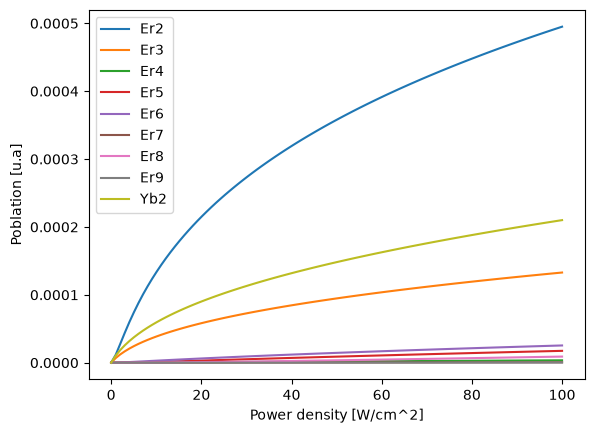

In [12]:
sim = Simulator(system)
steady = SteadyState()

energy_flux_values = np.linspace(0, 100, 100) * u.W / u.cm**2
res = steady.sweep(sim, variable=AndersonModel.energy_flux, values=energy_flux_values)
res.to_dataframe().drop(columns=["time", "event", "Er1", "Yb1"]).plot()
plt.xlabel("Power density [W/cm^2]")
plt.ylabel("Poblation [u.a]")
plt.show()

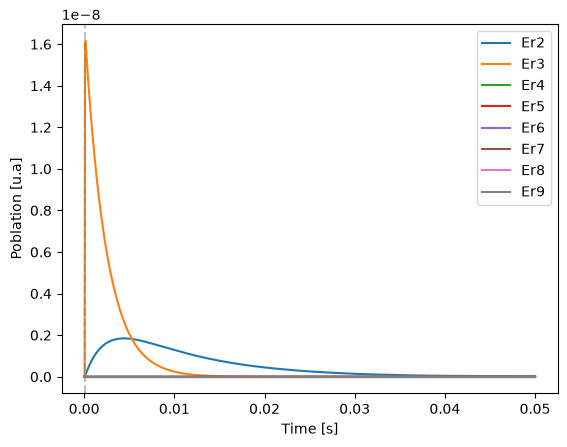

In [ ]:
from upconversion_models.jablonski_patch import piecewise
from poincare import solvers

sim = Simulator(system)

pulse_width = .1e-3 * u.s 
pulse_height = .01e-3 * u.J / u.cm**2 / pulse_width

pulse = {
    0 * u.s: {system.energy_flux: pulse_height},
    pulse_width: {system.energy_flux: 0 * u.W / u.cm**2},
}

res = piecewise(
    sim, events=pulse, save_at=np.linspace(0, 5e-2, 1000), solver=solvers.LSODA(rtol = 1e-10, atol=1e-10)
).to_dataframe()

res.drop(columns=["Er1", "Yb2", "Yb1"]).plot()

plt.xlabel("Time [s]")
plt.ylabel("Poblation [u.a]")

plt.axvline(pulse_width.magnitude, ls = '--', alpha=0.5, color='gray')
plt.show()

/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/scipy_events/_core.py:72: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = self.solver_cls(*args, **kwargs)
/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/xarray/core/variable.py:335: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


<Axes: xlabel='time'>

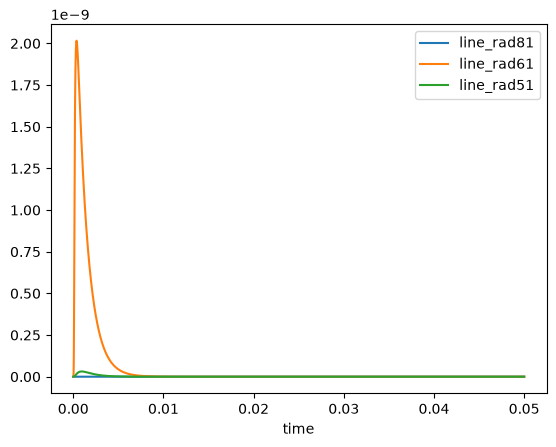

In [5]:
from upconversion_models.jablonski_patch import spectral_time_resolved_emission
spectra = spectral_time_resolved_emission(
    system,
    excitation=pulse,
    save_at=np.linspace(0, 5e-2, 10000),
    kind="fluorescence",
    solver = solvers.LSODA(rtol = 1e-14, atol=1e-14)
)

res = spectra.to_dataframe()
res.drop(columns=["line_rad"])[
    ["line_rad81", "line_rad61", "line_rad51"]
].plot()

Text(0, 0.5, 'normalized_intensity [u.a]')

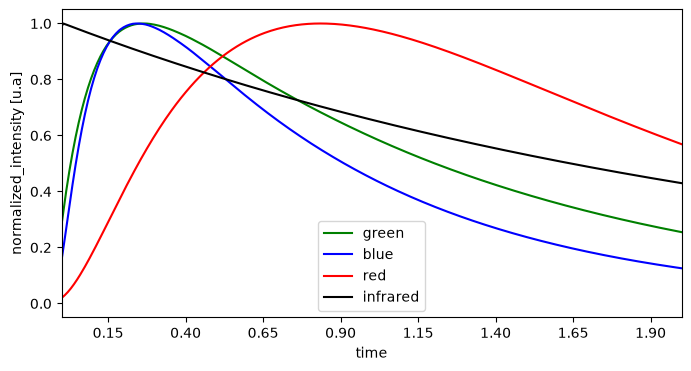

In [6]:
from matplotlib.ticker import FuncFormatter


df = res.copy()
df["green"] = df["line_rad61"]
df["red"] = df["line_rad51"]
df["blue"] = df["line_rad81"]
df["infrared"] = df["line_rad31"]

df = df[["green", "blue", "red", "infrared"]]
df.div(df.max()).plot(color=["green", "blue", "red", "black"], figsize=(8,4))
plt.xlim(pulse_width.magnitude, pulse_width.magnitude + 0.002)
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{((x - pulse_width.magnitude)* 1e3):.2f}")
)
plt.ylabel('normalized_intensity [u.a]')

/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/xarray/core/variable.py:335: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


(300.0, 800.0)

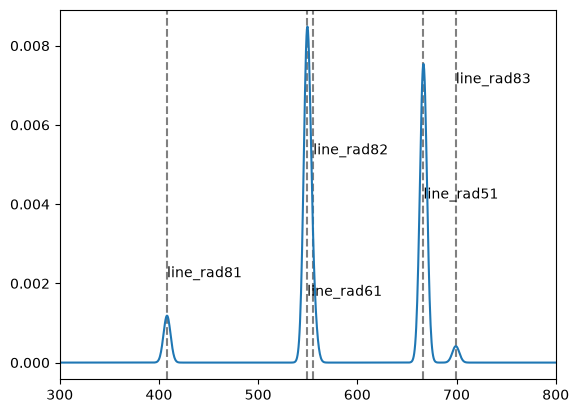

In [8]:
from jablonski.plots import graph_spectra
from jablonski.util import emission_transitions
from upconversion_models.constants import h, c

system = AndersonModel()

lines = {
    f"line_{transition}": transition
    for transition in emission_transitions(system, kind="fluorescence")
}

transform = {k: v.radiative_decay.rate_law for k, v in lines.items()}

sim = Simulator(system, transform=transform, append_transform=True)

steady = SteadyState(solver=solvers.LSODA())

ds = steady.solve(sim, values={AndersonModel.energy_flux: 25 * u.W * u.cm**-2})

for line in lines:
    ds.attrs[line] = lines[line].energy_difference


def gaussian(x, mu, A, sigma):
    return A * np.exp(-(((x - mu) / sigma) ** 2))


x = np.linspace(300, 800, 1000)
y = x * 0
for line in lines:
    wv = 1 / (ds.attrs[line].magnitude / (h * c)).magnitude * 1e7
    y += gaussian(x, wv, ds[line].values.item(), 5)
    plt.axvline(wv, label=line, ls='--',c="gray")
    if wv < 700:
        plt.text(wv,np.random.random() * 0.008, line)

plt.plot(x, y)
plt.xlim(
    300,
    800,
)

In [9]:
import xarray as xr

system = AndersonModel()

lines = {
    f"line_{transition}": transition
    for transition in emission_transitions(system, kind="fluorescence")
}

transform = {k: v.radiative_decay.rate_law for k, v in lines.items()} | {
    "abs": system.abs.absorption.rate_law
}

sim = Simulator(system, transform=transform, append_transform=True)

steady = SteadyState(solver=solvers.LSODA())

values = np.arange(0, 100, 1) * u.W / u.cm**2
results = {v: steady.solve(sim, values={AndersonModel.energy_flux: v}) for v in values}

res = xr.Dataset(
    {
            line: xr.DataArray(
                np.array(
                    [results[val][line].values.item() for val in values],
                ) ,
                dims=str(AndersonModel.energy_flux),
                coords={str(AndersonModel.energy_flux): values},
            )
        for line in transform
    }
).to_dataframe()

([<matplotlib.axis.XTick at 0x30b8fd450>,
 [Text(0, 0, '0'),
  Text(25, 0, '25'),
  Text(50, 0, '50'),
  Text(75, 0, '75'),
  Text(100, 0, '100')])

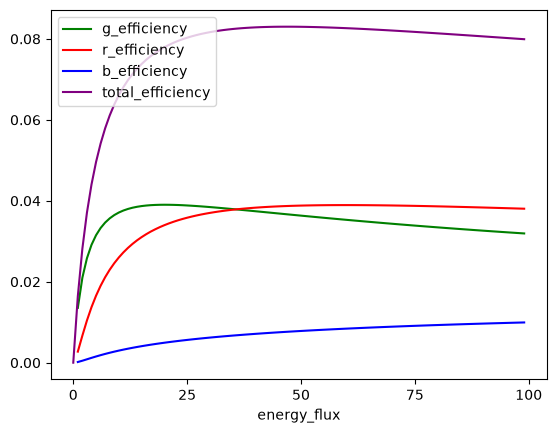

In [10]:
df = res.copy()
df["green"] =  df['line_rad61']
df['red'] = df['line_rad51']
df['blue'] = df['line_rad81']

df["g_efficiency"] = df['green'] / df['abs']
df['r_efficiency'] = df['red'] / df['abs']
df['b_efficiency'] = df['blue'] / df['abs']
df['total_efficiency'] = df[['g_efficiency','r_efficiency','b_efficiency']].sum(axis=1)

df[['g_efficiency','r_efficiency','b_efficiency','total_efficiency']].plot(color=['green', 'red', 'blue', 'purple'])    


plt.xticks(np.arange(0,101, 25))